In [10]:
# Final Year Project - Deepfake Detection Using Vision Transoformers

!pip install evaluate

In [11]:
################################### IMPORTS ###################################
import torch # using PyTorch
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms # for data augmentation
from torchvision.transforms import v2 # also for augmentation
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from IPython.display import Image
from torchvision import datasets
import pandas as pd
from transformers import AutoImageProcessor
from torch import nn
from torch.nn import Module, ModuleList
import math
# for training
import time
from transformers import TrainingArguments
from transformers import Trainer as Trainer1 #helps avoid confusion between methods 1 and 2
import time #for measuring duration of training methods
from sklearn.metrics import accuracy_score #method 1
from google.colab import drive # for CUDA
drive.mount('/content/drive', force_remount=True)
import evaluate


Mounted at /content/drive


In [39]:
################################ CONFIGURATION #################################

config = {
    "image_size": 72,
    "patch_size": 6,
    "dim": 192,
    "nr_channels": 3,
    "nr_layers": 4,
    "nr_heads": 12,
    "nr_classes": 2, # real or fake
    "dropout": 0.1,
    "r_mlp": 4,
}

################################ TRAINING ARGS #################################

train_args = {
    "learning_rate": 0.0003,
    "weight_decay": 0.01,
    "batch_size":  256,
    "epochs" : 40,
    "num_workers": 2, #2 cores from colab free
    "pin_memory": True
}

In [ ]:
import os
print(os.cpu_count())

12


In [13]:
################################## DATA PATHS ##################################
base_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Dataset" # path to my drive
#base_path = "/content/Dataset" # path to local data

#train, test, val data paths # # ~ 190.3k otal
train_path = base_path + "/Train" #~140k (70k real, 70k fake)
val_path = base_path + "/Validation" #~39.4k (~19700 real, -//- fake)
test_path = base_path + "/Test" #~10.9k (~5450 real, -//- fake)

############################## DATA AUGMENTATION ###############################

# https://docs.pytorch.org/vision/0.22/transforms.html
# recommended by pytorch for Image Classification
# additions from https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb

train_transforms = v2.Compose([
    v2.ToImage(), # needed only if PIL image
    v2.Resize((config["image_size"], config["image_size"])),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


################################# LOADING DATA #################################
# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb

# Load data
train_data = datasets.ImageFolder(train_path, train_transforms)
val_data = datasets.ImageFolder(val_path, val_transforms)
test_data = datasets.ImageFolder(test_path, test_transforms)

dataloaders = {
    "train": DataLoader(train_data, batch_size=train_args["batch_size"], shuffle=True),
    "val": DataLoader(val_data, batch_size=train_args["batch_size"], shuffle=False),
    "test": DataLoader(test_data, batch_size=train_args["batch_size"], shuffle=False)
}

dataset_sizes = {
    "train": len(train_data),
    "val": len(val_data),
    "test": len(test_data)
}
class_names = train_data.classes

#pirnting info
print(f"Classes: {class_names}")
print(f"Train dataset size: {dataset_sizes["train"]}")
print(f"Validation dataset size: {dataset_sizes["val"]}")
print(f"Test dataset size: {dataset_sizes["test"]}")

Classes: ['Fake', 'Real']
Train dataset size: 140002
Validation dataset size: 39428
Test dataset size: 10905


In [14]:
################################## ViT MODEL ###################################

# patch embedding
class PatchEmbeddings(Module):
    #converting images into patches

    def __init__(self, config):
        super().__init__()
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.emb_dim = config["dim"]
        self.nr_channels = config["nr_channels"]

        self.nr_patches = (self.image_size // self.patch_size) ** 2

        self.project = nn.Conv2d(self.nr_channels, self.emb_dim, kernel_size=self.patch_size, stride=self.patch_size)


    def forward(self, x):
        #batch size, channels, img height, img width > b, emb_dim, patch col, patch row
        x = self.project(x)

        # b, emb_dim, patch col, patch row > b, emb_dim, nr_patches
        x = x.flatten(2)

        #b, dim, patch > b, nr_patches, emb_dim
        x = x.transpose(1,2)

        return x


#positional encoding and class token
class PositionalEmbeddings(Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embeddings = PatchEmbeddings(config)
        nr_patches = (config["image_size"] // config["patch_size"]) ** 2

        # creating classification token
        self.cls_token = nn.Parameter(torch.randn(1, 1, config["dim"]))

        # position emb for the csl token and patches
        self.position_emb = nn.Parameter(torch.randn(1, nr_patches + 1, config["dim"]));

    def forward(self, x):
        # x = self.position_emb(x)
        B = x.size(0)
        x = self.patch_embeddings(x)
        # getting batch size, nr patches and dim
        # b, n, _ = x.shape

        # expanding tokens
        #cls_tokens = self.cls_token.expand(b, -1, -1)
        #tokens = self.cls_token.expand(x.size()[0], -1, -1) # only expanding batch dim, nothing else
        tokens = self.cls_token.expand(B, -1, -1)
        # concatenate token to start of patches
        x = torch.cat((tokens, x), dim = 1)

        # adding positional encoding to embeddins before being outputted
        x = x + self.position_emb
        return x

#single attention head
class Attention(Module):
    #global relationships between patches
    #dependency modelling and spatial context

    def __init__(self, config, head_size):
        super().__init__()
        self.head_size = head_size
        self.dim = config["dim"]
        # inner_dim = self.dim * self.nr_heads
        self.dropout = nn.Dropout(config["dropout"]) #dropout used to prevent overfitting

        self.key = nn.Linear(self.dim, self.head_size)
        self.val = nn.Linear(self.dim, self.head_size)
        self.query = nn.Linear(self.dim, self.head_size)

        #self.to_qkv = nn.Linear(self.dim, inner_dim * 3) # into kets, vals and queries

    def forward(self, x):
        #qkv = self.to_qkv(x).chunk(3, dim = -1)
        #batch_size, nr_patches, inner_dim TO nr_heads, nr_patches, dim_head
        #query, key, val = map(lambda t: rearrange(t), qkv)
        key = self.key(x)
        val = self.val(x)
        query = self.query(x)

        # score = how similar the patch is to other pathces
        # probs = scores but changed to weights
        # output = final result of each head, basically a weighted average of info

        attn_scores = (torch.matmul(query, key.transpose(-1,-2))) / math.sqrt(self.head_size)
        attn_probs = nn.functional.softmax(attn_scores, dim = -1)
        attn_probs = self.dropout(attn_probs)
        output = torch.matmul(attn_probs, val)
        return (output, attn_probs)

class MultiHeadAttention(Module):
    # parallel attention heads
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.nr_heads = config["nr_heads"]
        self.head_size = self.dim // self.nr_heads
        self.heads = nn.ModuleList([Attention(config, self.head_size) for _ in range(self.nr_heads)])

        self.to_out = nn.Linear(self.dim, self.dim)

    def forward(self, x):
        out = torch.cat([head(x)[0] for head in self.heads], dim = -1) # 0 gives output, 1 gives probs
        output = self.to_out(out)
        return output


# Multilayer Perceptron / Feed forward Network
class MLP(Module):
    #intorduces non-linearity and for learning complex features
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.dropout = config["dropout"]
        self.r_mlp = config["r_mlp"]
        hidden_dim = self.dim * self.r_mlp
        self.mlp = nn.Sequential(
            nn.Linear(self.dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_dim, self.dim),
            nn.Dropout(self.dropout)
        )


    def forward(self,x):
        output= self.mlp(x)
        return output


# transofmrer encoder blocks (self attention and Multilayer Perceptron (mlp))
class Encoder(Module):
    # transformer encoder module:
    #layer normalisation
    # multi-head attention
    # residual connections
    # multi layer perception

    def __init__(self, config):
        super().__init__()
        # self.nr_heads = config["nr_heads"]
        self.dim = config["dim"]
        # self.r_mlp = config["r_mlp"]
        # self.dropout = nn.Dropout(config["dropout"])
        #hidden_dim = self.dim * self.r_mlp

        #layer normalisation
        self.norm = nn.LayerNorm(self.dim)
        # multi-head attention
        self.mha = MultiHeadAttention(config)
        # multi layer perception
        self.mlp = MLP(config)
        #nn.Sequential(
        #    nn.Linear(self.dim, hidden_dim),
        #    nn.GELU(), # or ReLU ???
        #    nn.Linear(hidden_dim, self.dim)
        #)
        #self.layers = nn.ModuleList([])


    def forward(self, x):
        x = x + self.mha(self.norm(x)) # after sublayer 1
        output = x + self.mlp(self.norm(x)) #after sublayer 2
        return output

#classification head
class ViTForClassification(Module):

        # self.depth = 0; # how many transformer layers
        # self.batch_size = 0;
        # self.emb_dropout = 0; # dropout rate for embedding

    #def __init__(self, dim, nr_classes, img_size, patch_size, nr_channels, nr_heads, nr_layers):
    def __init__(self,config):
        super().__init__()

        #self.encoder = Encoder(config)
        #self.classifier = nn.Linear(hidden_size, nr_classes)

        # following config build
        self.dim = config["dim"]
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.nr_heads = config["nr_heads"]
        self.nr_channels = config["nr_channels"]
        self.nr_classes = config["nr_classes"]
        self.dropout = config["dropout"]
        self.loss_fn = nn.CrossEntropyLoss()

        #going through each class
        self.positional_emb = PositionalEmbeddings(config)
        #self.cls_token = nn.Parameter(torch.randn(1,1, self.dim))
        #self.encoders = Encoder(config)
        self.encoders = nn.ModuleList([Encoder(config) for _ in range(config["nr_layers"])])
        self.norm = nn.LayerNorm(self.dim)
        # linear layer to project encoders output to nr of classes
        self.classifier = nn.Linear(self.dim, self.nr_classes)

#https://huggingface.co/docs/transformers/v4.27.0/en/main_classes/trainer
    def forward(self, img, labels=None):
        #now running data through each class
        x = self.positional_emb(img) #positional and patch emb
        for layer in self.encoders:
            x = layer(x)

        x = self.norm(x)
        output = self.classifier(x[:, 0])

        #A7
        loss = None
        if labels is not None: #for training method 1
            loss = self.loss_fn(output, labels)
            return (loss, output)

        return output


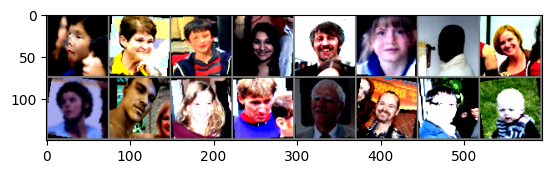

Labels:  Fake | Real | Real | Real | Fake | Real | Fake | Real | Real | Fake | Fake | Real | Fake | Real | Real | Real


In [15]:
################################### CONFIG RUNS ##################################

# https://stackoverflow.com/questions/59005242/how-to-get-n-number-of-images-from-torchvision-datasets-imagefolder
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html


#dataset = torchvision.datasets.ImageFolder(...)
np.random.seed(42) # for fair comparisons
train_subset = torch.utils.data.Subset(train_data, np.random.choice(len(train_data), 20000, replace=False))
val_subset = torch.utils.data.Subset(val_data, np.random.choice(len(val_data), 5000, replace=False))

subsetloaders = {
    "train": DataLoader(train_subset, batch_size=train_args["batch_size"], shuffle=True),
    "val": DataLoader(val_subset, batch_size=train_args["batch_size"], shuffle=False)
}

def imshow(img):
    # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    img = img / 2 + 0.5     # unnormalize, tho not fully so colours will be slightly off (but this is insignificant for a small scale run)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(subsetloaders["train"])
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:16])) # showing only 10 images for display
# print labels
print('Labels: ', ' | '.join(f'{class_names[labels[j]]}' for j in range(16)))

In [40]:
################################### TRAINING ###################################
# METHOD THREE

torch.manual_seed(42)

device = "cuda"if torch.cuda.is_available() else "cpu"
print(device)

loss_fn = nn.CrossEntropyLoss()

model = ViTForClassification(config).to(device)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])


criterion = nn.CrossEntropyLoss().to(device)

################################## CHECKPOINTS #################################
checkpoint_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Checkpoints/config_8.pt" #saving pt file for each config tested


train_losses = []
val_losses = []

#method three
# https://github.com/pytorch/examples/blob/main/imagenet/main.py
class AverageMeter(object):
    def __init__(self, name):
        self.name = name
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target):
    with torch.no_grad():
        batch_size = target.size(0)
        _, pred = output.topk(1, 1, True, True)
        pred = pred.t()

        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
        res= correct_1.mul_(100.0 / batch_size)
        return res


def train(train_loader, model, criterion, optimizer, device):
    losses = AverageMeter("Loss")

    # switch to train mode
    model.train()
    print(f"Training started")

    start = time.time()
    for i, (images, target) in enumerate(train_loader):

        if i % 10 == 0:
          print(f"Batch {i}")
        # move data to the same device as model
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # compute output
        output = model(images)
        loss = criterion(output, target)

        #record loss
        losses.update(loss.item(), images.size(0))

        # compute gradient and do SGD step
        optimizer.zero_grad() #clearing old gradients
        loss.backward() #new gradients
        optimizer.step() #updating weights

    return losses.avg


def validate(valloader, model, criterion, device):
    model.eval()
    losses = AverageMeter("Loss")
    acc = AverageMeter("Accuracy")

    model.eval()

    with torch.no_grad():
        for i, (images, target) in enumerate(valloader):
            images = images.to(device)
            target = target.to(device)

            output = model(images)
            loss = criterion(output, target)

            #calculating accuracy for method comparison
            acc1 = accuracy(output, target).item()

            losses.update(loss.item(), images.size(0))
            acc.update(acc1, images.size(0))

    return losses.avg, acc.avg



#avg loss from https://github.com/aidendorian/Vision-Transformer-for-DeepFake-Detection/blob/master/pre_training.py
start_time = time.time()
best_acc = 0
start_epoch = 0 # for checkpointing

for epoch in range(start_epoch, train_args["epochs"]):
    e_start_time = time.time()
    # for small run
    train_loss = train(subsetloaders["train"], model, criterion, optimizer,device)
    val_loss, acc = validate(subsetloaders["val"],model, criterion, device)
    e_end_time = time.time()
    #main runs
    #train_loss = train(dataloaders["train"], model, criterion, optimizer,device)
    #val_loss, acc = validate(dataloaders["val"],model, criterion, device)

    #for loss curves
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    best_acc = max(acc, best_acc)

    #https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/dbcf5e6a5e95bf9f7a0e49e123c13b60/saving_and_loading_a_general_checkpoint.ipynb#scrollTo=GZZi4Al2lt4H
    #creating checkpoint at each epoch incase of Colab "timeout"
    torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_acc": best_acc,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "config": config,
                "train_args": train_args
                }, checkpoint_path )
    if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%,  Highest Accuracy: {best_acc:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")

cuda
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Epoch: 1, Time: 116.00s, Train loss: 0.6718, Validation loss: 0.5625,  Accuracy: 71.38%,  Highest Accuracy: 71.38%
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Epoch: 5, Time: 116.93s, Train loss: 0.4550, Validation loss: 0.4902,  Accuracy: 75.46%,  Highest Accuracy: 75.46%
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40
Batch 50
Batch 60
Batch 70
Training started
Batch 0
Batch 10
Batch 20
Batch 30
Batch 40


In [ ]:
################################ LOAD CHECKPOINT ###############################

# for loading from checkpoint if timed out
#checkpoint = torch.load(checkpoint_path)
#model.load_state_dict(checkpoint['model_state_dict'])
#optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#start_epoch = checkpoint["epoch"] + 1
#best_acc = checkpoint["best_acc"]
#train_losses = checkpoint["train_losses"]
#val_losses = checkpoint["val_losses"]

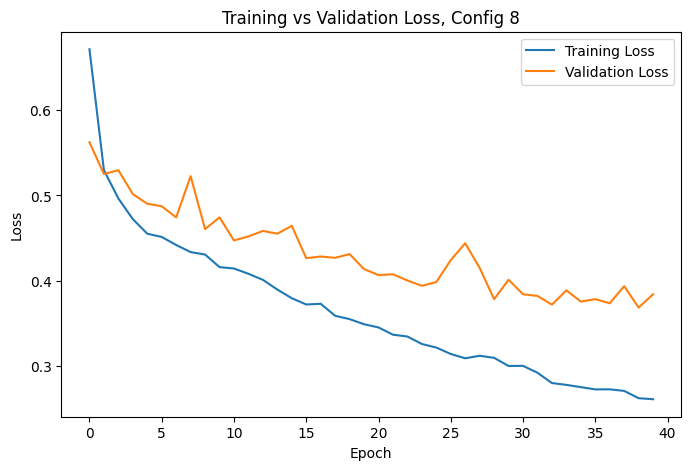

In [41]:
################################### LOSS CURVES ##################################
#https://www.geeksforgeeks.org/deep-learning/training-and-validation-loss-in-deep-learning/
# plotting loss graphs
plt.figure(figsize=(8,5))
plt.title("Training vs Validation Loss, Config 8")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()